# 2. Tehnici de clasificare

Exemplu: Setul de date supplementary_demographics.csv contine 4500 de inregistrari referitoare la clientii unui magazin. Coloanele con'in caracteristici ale clientilor precum: CUST_ID, EDUCATION, OCCUPATION, HOUSE_HOLD_SIZE, dar si atribute referitoare la achizitiile de electronice din magazin si tipul acestora.
Obiectivul este sa determinam probabilitatea de achizitie a unui anumit produs (Y_BOX_GAMES) pe baza obiectelor achizitionate anterior.

In [ ]:
import pandas as pd
pd.set_option('display.max_columns',None)
#pd.set_option('display.max_rows', None)
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns

#### Definim functii pentru afisarea metricilor modelelor

Functie pentru afisarea confusion matrix


O matrice de confuzie este un tabel care arată cât de bine a prezis modelul  rezultatele unui set de date de test. Este folosită pentru a evalua performanța modelelor de clasificare. Matricea compară valorile reale (adevărul) cu valorile prezise (ce a spus modelul).

Structura matricei de confuzie

Matricea de confuzie este formată din 4 componente principale pentru o problemă de clasificare binară (2 clase):


	TP	FN
	FP	TN
  
Explicații:


True Positive (TP): Modelul a prezis corect clasa pozitivă.
Exemplu: A prezis "bolnav" și persoana chiar este bolnavă.

True Negative (TN): Modelul a prezis corect clasa negativă.
Exemplu: A prezis "sănătos" și persoana chiar este sănătoasă.

False Positive (FP): Modelul a prezis greșit clasa pozitivă (fals alarmă).
Exemplu: A prezis "bolnav", dar persoana este sănătoasă.

False Negative (FN): Modelul a prezis greșit clasa negativă (a ratat un caz).
Exemplu: A prezis "sănătos", dar persoana este bolnavă.



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
def conf_mtrx(y_test, y_pred, model_name):
    # 1. Calculează matricea de confuzie
    cm = confusion_matrix(y_test, y_pred)

    # 2. Creează un plot (dimensiuni 5x5)
    f, ax = plt.subplots(figsize=(5, 5))

    # 3. Creează heatmap pentru matricea de confuzie
    sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)

    # 4. Adaugă etichete pentru axe și titlu
    plt.xlabel("predicted y values")
    plt.ylabel("real y values")
    plt.title("\nConfusion Matrix " + model_name)

    # 5. Afișează graficul
    plt.show()

# Functie pentru afisarea curbei ROC si AUC


Curba ROC  este un instrument utilizat pentru a evalua performanța unui model de clasificare. Aceasta arată cât de bine poate modelul să diferențieze între cele două clase (pozitiv și negativ) la diferite praguri de decizie.

Cum funcționează?

True Positive Rate (TPR): Cât de bine identifică modelul toate cazurile pozitive.

𝑇𝑃𝑅 = Cazuri pozitive corecte (True Positives)/
Total cazuri pozitive (True Positives + False Negatives)


False Positive Rate (FPR): Cât de des clasifică modelul greșit cazuri negative ca fiind pozitive.

𝐹𝑃𝑅 =Cazuri negative greșit clasificate (False Positives) /
Total cazuri negative (False Positives + True Negatives)


Pragul de Decizie:

Modelul face predicții bazate pe probabilități. De exemplu, dacă probabilitatea este mai mare decât un anumit prag (de obicei 0.5), modelul clasifică un caz ca pozitiv.
Prin modificarea acestui prag, TPR și FPR se schimbă. Curba ROC arată cum se comportă modelul la toate pragurile posibile.


**Interpretarea Curbei ROC**

*Forma Curbei:*

Dacă curba ROC se apropie de colțul din stânga sus, modelul este foarte bun, având un TPR mare și un FPR mic.
Dacă curba este aproape de diagonală, modelul ghicește, având performanțe similare unui clasament aleator.


AUC (Area Under the Curve):

AUC este aria de sub curba ROC și variază între 0 și 1:

AUC = 1: Model perfect.

AUC = 0.5: Model care ghicește (nicio capacitate de clasificare).

AUC < 0.5: Model mai slab decât ghicitul aleator (foarte rar).


De ce este utila curba ROC?


Compararea modelelor:

Curba ROC permite compararea mai multor modele pentru a vedea care diferențiază cel mai bine între clase.

Alegerea pragului optim:

Din curba ROC, poți alege pragul care oferă echilibrul optim între TPR și FPR, în funcție de aplicație.

Performanță Globală:


AUC oferă o măsură globală a cât de bine se descurcă modelul, indiferent de prag.

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
def roc_auc_curve_plot(model_name, X_testt, y_testt):
    """
    Funcție pentru a afișa curba ROC-AUC a unui model de clasificare.
    Curba ROC vizualizează cât de bine poate modelul să distingă între clasele pozitive și negative.

    Parametri:
    - model_name: Modelul de clasificare antrenat.
    - X_testt: Setul de date de testare (variabilele de intrare).
    - y_testt: Valorile reale (etichetele adevărate) pentru setul de testare.
    """

    # Pasul 1: Creăm probabilitățile de bază pentru un model "No Skill"
    # Modelul "No Skill" presupune că nu se face nicio predicție pozitivă (toate probabilitățile sunt 0)

    ns_probs = [0 for _ in range(len(y_testt))]
    # Pasul 2: Obținem probabilitățile prezise de model pentru clasa pozitivă
    # predict_proba returnează probabilitățile pentru ambele clase (negative și pozitive)
    # Selectăm doar probabilitățile pentru clasa pozitivă
    model_probs = model_name.predict_proba(X_testt)[:, 1]

    # Pasul 3: Calculăm scorurile AUC (Area Under the Curve)
    # AUC măsoară abilitatea modelului de a distinge între clase
    # ns_auc: Scorul AUC pentru modelul "No Skill" (ar trebui să fie 0.5, adică random guessing)
    ns_auc = roc_auc_score(y_testt, ns_probs)
    # lr_auc: Scorul AUC pentru modelul antrenat (cu cât mai mare, cu atât mai bine, max = 1.0)
    lr_auc = roc_auc_score(y_testt, model_probs)

    # Afișăm scorurile AUC calculate
    print('No Skill: ROC AUC=%.3f' % (ns_auc))  # Scorul AUC pentru modelul de bază
    print('Model: ROC AUC=%.3f' % (lr_auc))     # Scorul AUC pentru modelul dat

    # Pasul 4: Generăm datele pentru curba ROC
    # ROC (Receiver Operating Characteristic) necesită calcularea TPR (True Positive Rate) și FPR (False Positive Rate)
    # ns_fpr, ns_tpr: Ratele pentru modelul "No Skill"
    ns_fpr, ns_tpr, _ = roc_curve(y_testt, ns_probs)
    # model_fpr, model_tpr: Ratele pentru modelul nostru de clasificare
    model_fpr, model_tpr, _ = roc_curve(y_testt, model_probs)

    # Pasul 5: Desenăm curba ROC
    # Curba ROC pentru modelul "No Skill" (linie punctată)
    plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
    # Curba ROC pentru modelul nostru de clasificare
    plt.plot(model_fpr, model_tpr, marker='.', label='Classifier')

    # Pasul 6: Adăugăm etichete, legendă și afișăm graficul
    # Eticheta pentru axa X: Rata fals pozitivă (False Positive Rate)
    plt.xlabel('False Positive Rate')
    # Eticheta pentru axa Y: Rata adevărat pozitivă (True Positive Rate)
    plt.ylabel('True Positive Rate')
    # Adăugăm legenda pentru a identifica liniile
    plt.legend()
    # Afișăm graficul
    plt.show()


    plt.show()

### Extragerea datelor si analiza exploratorie:

In [ ]:
data = pd.read_csv('supplementary_demographics.csv')

In [ ]:
data.describe()

,CUST_ID,YRS_RESIDENCE,AFFINITY_CARD,BULK_PACK_DISKETTES,FLAT_PANEL_MONITOR,HOME_THEATER_PACKAGE,BOOKKEEPING_APPLICATION,PRINTER_SUPPLIES,Y_BOX_GAMES,OS_DOC_SET_KANJI
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.0,4500.000000,4500.000000
mean,102250.500000,4.022000,0.238222,0.637333,0.577111,0.564222,0.885111,1.0,0.312444,0.002444
std,1299.182435,1.901955,0.426043,0.480823,0.494073,0.495913,0.318923,0.0,0.463541,0.049386
min,100001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000
25%,101125.750000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0,0.000000,0.000000
50%,102250.500000,4.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,0.000000
75%,103375.250000,5.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,0.000000
max,104500.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000


In [ ]:
data.head()

,CUST_ID,EDUCATION,OCCUPATION,HOUSEHOLD_SIZE,YRS_RESIDENCE,AFFINITY_CARD,BULK_PACK_DISKETTES,FLAT_PANEL_MONITOR,HOME_THEATER_PACKAGE,BOOKKEEPING_APPLICATION,PRINTER_SUPPLIES,Y_BOX_GAMES,OS_DOC_SET_KANJI,COMMENTS
0,102547,10th,Other,1,0,0,1,1,0,0,1,1,0,NaN
1,101050,10th,Other,1,0,0,1,1,0,0,1,1,0,NaN
2,100040,11th,Sales,1,0,0,1,1,0,0,1,1,0,NaN
3,102117,HS-grad,Farming,1,0,0,0,0,0,1,1,1,0,NaN
4,101074,10th,Handler,1,1,0,1,1,0,0,1,1,0,NaN


Lista coloanelor numerice si non-numerice:

In [ ]:
print(data.select_dtypes(include=np.number).columns.tolist())

['CUST_ID', 'YRS_RESIDENCE', 'AFFINITY_CARD', 'BULK_PACK_DISKETTES', 'FLAT_PANEL_MONITOR', 'HOME_THEATER_PACKAGE', 'BOOKKEEPING_APPLICATION', 'PRINTER_SUPPLIES', 'Y_BOX_GAMES', 'OS_DOC_SET_KANJI']


In [ ]:
print(data.select_dtypes(exclude=np.number).columns.tolist())

['EDUCATION', 'OCCUPATION', 'HOUSEHOLD_SIZE', 'COMMENTS']


Analizam distribuita variabilelor, variabila target - Y_BOX_GAMES


array([[<Axes: title={'center': 'CUST_ID'}>,
        <Axes: title={'center': 'YRS_RESIDENCE'}>,
        <Axes: title={'center': 'AFFINITY_CARD'}>],
       [<Axes: title={'center': 'BULK_PACK_DISKETTES'}>,
        <Axes: title={'center': 'FLAT_PANEL_MONITOR'}>,
        <Axes: title={'center': 'HOME_THEATER_PACKAGE'}>],
       [<Axes: title={'center': 'BOOKKEEPING_APPLICATION'}>,
        <Axes: title={'center': 'PRINTER_SUPPLIES'}>,
        <Axes: title={'center': 'Y_BOX_GAMES'}>],
       [<Axes: title={'center': 'OS_DOC_SET_KANJI'}>, <Axes: >, <Axes: >]],
      dtype=object)

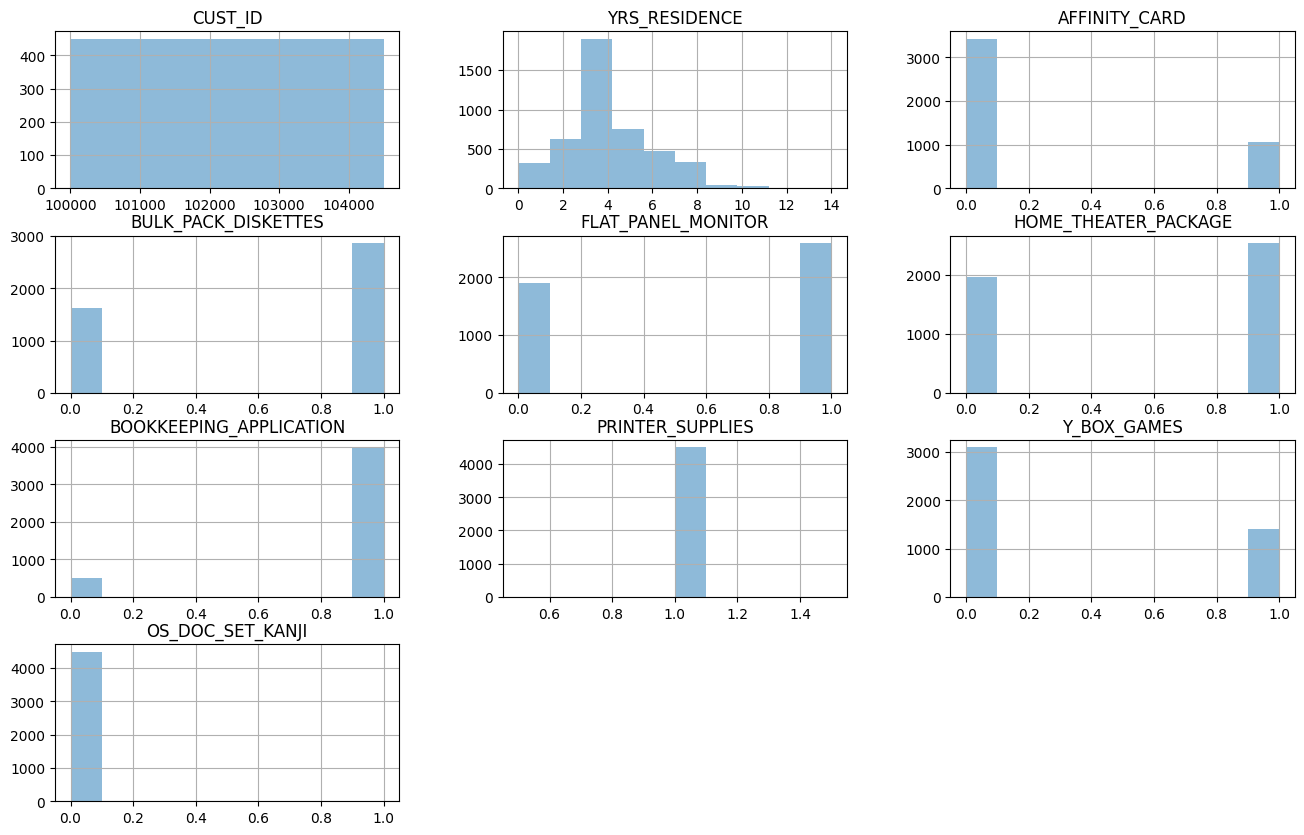

In [ ]:
data.hist(alpha=0.5, figsize=(16, 10))

Analizam existenta valorilor lipsa:

In [ ]:
total = data.isnull().sum().sort_values(ascending=False)
percent = (data.isnull().sum()*100/data.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
print(missing_data.head(20))

                         Total   Percent
COMMENTS                   205  4.555556
CUST_ID                      0  0.000000
OCCUPATION                   0  0.000000
HOUSEHOLD_SIZE               0  0.000000
YRS_RESIDENCE                0  0.000000
EDUCATION                    0  0.000000
AFFINITY_CARD                0  0.000000
BULK_PACK_DISKETTES          0  0.000000
HOME_THEATER_PACKAGE         0  0.000000
FLAT_PANEL_MONITOR           0  0.000000
BOOKKEEPING_APPLICATION      0  0.000000
PRINTER_SUPPLIES             0  0.000000
Y_BOX_GAMES                  0  0.000000
OS_DOC_SET_KANJI             0  0.000000


Analizam coloana COMMENTS. Numarul de comentarii unice:

In [ ]:
len(data['COMMENTS'].unique())

45

### Prelucrarea datelor

Inlocuirea valorilor lipsa din coloana COMMENTS

In [ ]:
data['COMMENTS'] = data['COMMENTS'].fillna('missing')

Transformam coloanele non-numerice in coloane numerice cu LabelEncoder():

In [ ]:
le = preprocessing.LabelEncoder()
data['EDUCATION']=le.fit_transform(data['EDUCATION'])
data['OCCUPATION']=le.fit_transform(data['OCCUPATION'])
data['HOUSEHOLD_SIZE']=le.fit_transform(data['HOUSEHOLD_SIZE'])
data['COMMENTS']=le.fit_transform(data['COMMENTS'])

Coeficientul de corelatie dintre variabilele numerice si target (Y_BOX_GAMES):

In [ ]:
corr = data.corr(method='pearson')
corr.sort_values(["Y_BOX_GAMES"], ascending = False, inplace = True)
print(corr.Y_BOX_GAMES)

Y_BOX_GAMES                1.000000
FLAT_PANEL_MONITOR         0.066560
OS_DOC_SET_KANJI           0.044305
BULK_PACK_DISKETTES        0.039800
CUST_ID                    0.000175
OCCUPATION                -0.012893
COMMENTS                  -0.021242
BOOKKEEPING_APPLICATION   -0.057835
EDUCATION                 -0.161182
HOUSEHOLD_SIZE            -0.294760
AFFINITY_CARD             -0.304941
YRS_RESIDENCE             -0.614130
HOME_THEATER_PACKAGE      -0.767052
PRINTER_SUPPLIES                NaN
Name: Y_BOX_GAMES, dtype: float64


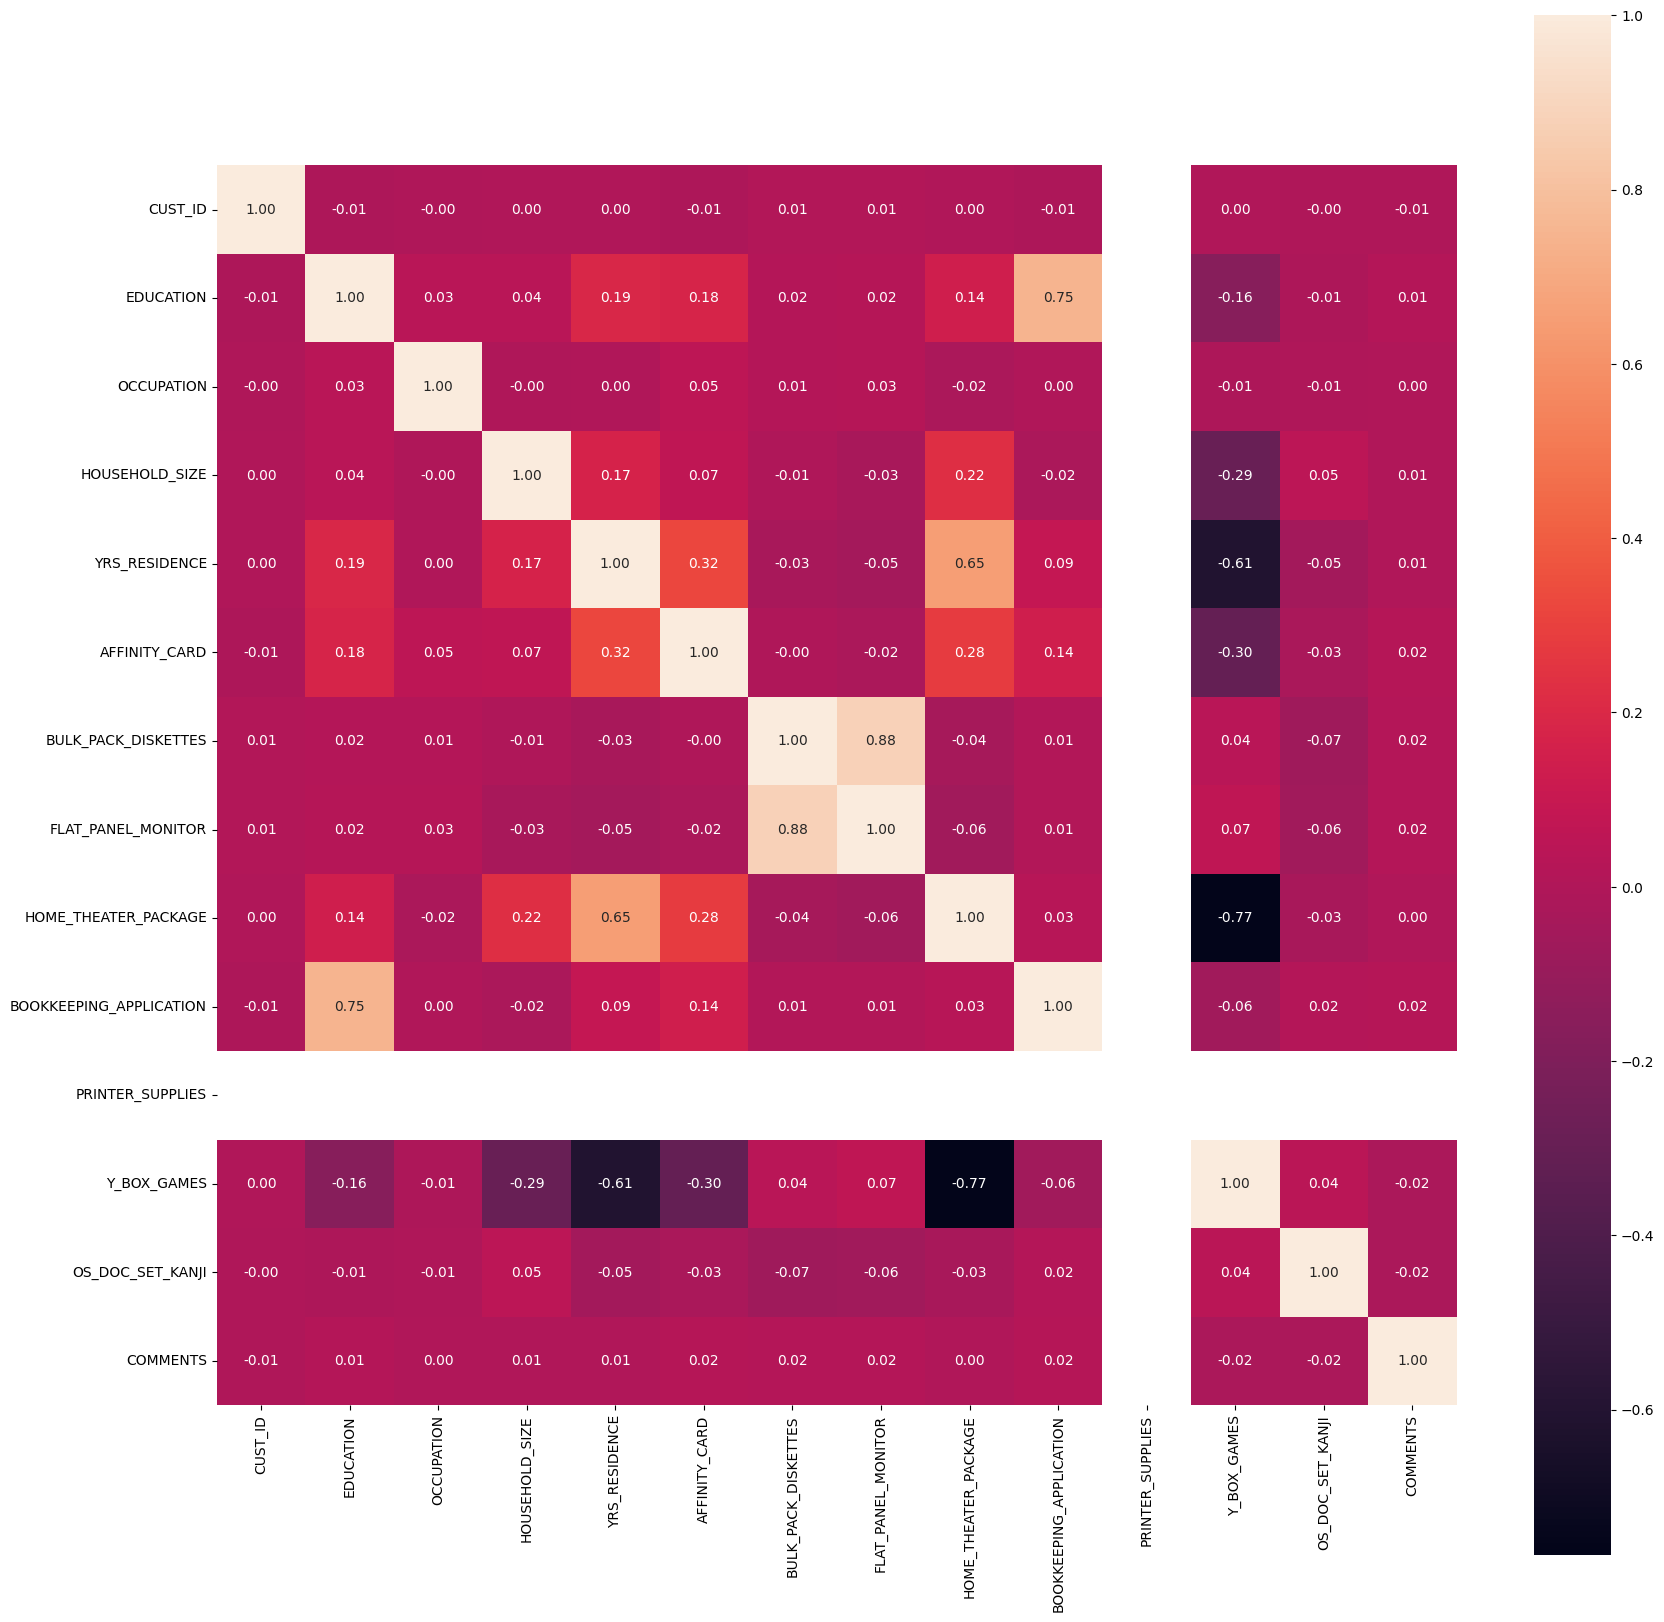

In [ ]:
corrmat = data.corr()
f, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(corrmat, vmax = 1, annot = True, fmt = ".2f",square=True);
plt.show()

Stergem din setul de date coloanele necorelate:

In [ ]:
data.drop("CUST_ID", axis = 1, inplace = True)
data.drop("BULK_PACK_DISKETTES", axis = 1, inplace = True)
data.drop("COMMENTS", axis = 1, inplace = True)
data.drop("BOOKKEEPING_APPLICATION", axis = 1, inplace = True)
data.drop("PRINTER_SUPPLIES", axis = 1, inplace = True)
data.drop("OS_DOC_SET_KANJI", axis = 1, inplace = True)
data.drop("EDUCATION", axis = 1, inplace = True)
data.drop("OCCUPATION", axis = 1, inplace = True)
#data.drop("HOUSEHOLD_SIZE", axis = 1, inplace = True)

In [ ]:
print(data.head())

   HOUSEHOLD_SIZE  YRS_RESIDENCE  AFFINITY_CARD  FLAT_PANEL_MONITOR  \
0               0              0              0                   1   
1               0              0              0                   1   
2               0              0              0                   1   
3               0              0              0                   0   
4               0              1              0                   1   

   HOME_THEATER_PACKAGE  Y_BOX_GAMES  
0                     0            1  
1                     0            1  
2                     0            1  
3                     0            1  
4                     0            1  


Deocamdata nu este necesara normalizarea valorilor de intrare.

Construirea seturilor de date de train si test: 80% train si 20% test.
Parametrul random_state=63 ne asigura ca se va selecta acelasi set de date de fiecare data cand rulam scriptul.

In [ ]:
X = data.drop(['Y_BOX_GAMES'], axis=1)
y = data['Y_BOX_GAMES']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=.15)

In [ ]:
#putem normaliza seturile de train si test
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

# Construirea modelului de predictie

Aplicam mai multe modele si retinem acuratetea modelelor intr-un dataframe

In [ ]:
acc_df = pd.DataFrame(columns = ['Model','Accuracy', 'F1-Score'])

#### 1. Regresia logistica
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression




Logistic Regression este un algoritm de clasificare folosit pentru a prezice probabilități între 0 și 1 și pentru a clasifica observațiile în clase (pozitivă sau negativă). Deși se numește „regression,” este utilizat pentru clasificare, nu pentru regresie propriu-zisă.

Scopul Logistic Regression este să calculeze probabilitatea ca o observație să aparțină unei clase specifice:

Rezultatul este o valoare numerică între 0 și 1, reprezentând probabilitatea.
Dacă probabilitatea este mai mare sau egală cu un prag (de obicei, 0.5), modelul clasifică observația ca „pozitivă” (clasa 1).
Dacă probabilitatea este sub prag, clasifică observația ca „negativă” (clasa 0).
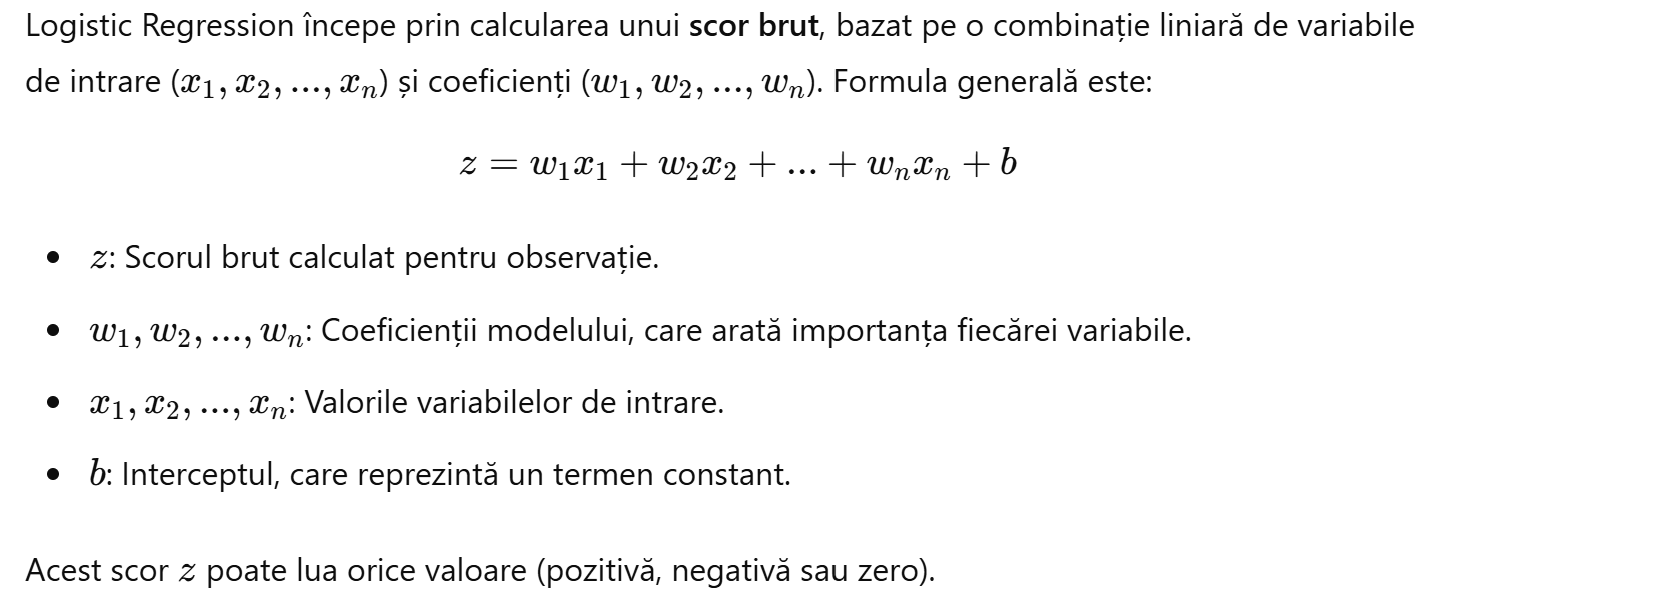
Funcția sigmoid este o formulă matematică utilizată pentru a transforma scorul brut intr-o probabilitate între 0 și 1. Este definită astfel:


 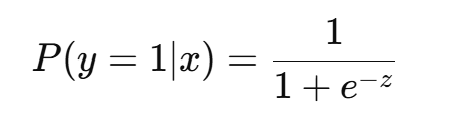

Cum funcționează:
Exponențiala negativă:
𝑒 la puterea −z reduce valoarea  dacă este foarte mare (pozitivă) sau o mărește dacă este foarte mică (negativă).
Fracția: Împărțind, funcția comprimă scorul brut astfel încât să fie întotdeauna între 0 și 1.
Dacă 𝑧 este mare și pozitiv, probabilitatea tinde spre 1.
Dacă 𝑧 este mic și negativ, probabilitatea tinde spre 0.
Dacă 𝑧  este 0, probabilitatea este exact 0.5.





In [ ]:
from sklearn.linear_model import LogisticRegression

Parametrii sunt:
- penalty - 'l2' utilizeaza regularizarea prin norma l2. Adaugă o penalizare pentru coeficienții mari, prevenind modelul să devină prea complex.
- max_iter - numarul de iteratii
- solver - {‘newton-cg’, ‘lbfgs’, ‘liblinear’, ‘sag’, ‘saga’}, default=’lbfgs’ Determină metoda matematică folosită pentru a calcula coeficienții (de exemplu, lbfgs este eficient pentru seturi mari de date).
- multi_class - {‘auto’, ‘ovr’, ‘multinomial’}, default=’auto’
- n_jobs - nr de CPU cores utilizate pentru executia in paralel in cazul in care multi_class='ovr'

In [ ]:
RL = LogisticRegression( max_iter=100,  penalty='l2', solver='lbfgs')

RL.fit(X_train, y_train)

LogisticRegression()

Obtinem predictia pe setul de test:

In [ ]:
y_predicted = RL.predict(X_test)

Afisam acuratetea, matricea de confuzie şi raportul de clasificare

Confusion matrix:
[[427  31]
 [ 27 190]]


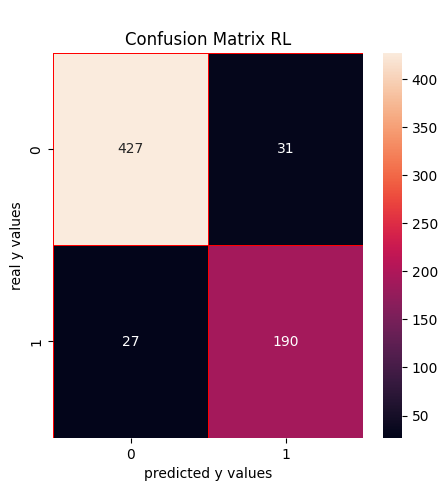

In [ ]:
CM=confusion_matrix(y_test, y_predicted)
print("Confusion matrix:")
print(CM)
conf_mtrx(y_test, y_predicted, 'RL')

Pentru fiecare clasă, classification_report oferă următoarele metrici:

Precision (Precizie): Procentul predicțiilor pozitive care sunt corecte.

Din toate observațiile clasificate ca pozitive, câte dintre ele sunt într-adevăr pozitive? O valoare mare indică faptul că modelul face mai puține alerte false (False Positives). Dacă precizia este scăzută, modelul clasifică greșit multe cazuri negative ca fiind pozitive.

Recall : Procentul de cazuri pozitive corect detectate. Din toate observațiile care ar trebui să fie clasificate ca pozitive, câte au fost detectate corect? O valoare mare indică faptul că modelul detectează aproape toate cazurile pozitive. Dacă recall-ul este scăzut, modelul ratează multe cazuri pozitive (False Negatives).

F1-Score: O combinație între precizie și recall, utilă pentru seturi de date dezechilibrate. F1-Score combină precision și recall într-o singură valoare. Este utilă mai ales când ai un set de date dezechilibrat, adică atunci când una dintre clase are mult mai multe exemple decât cealaltă.F1-Score este mare atunci când atât precizia, cât și recall-ul sunt mari. Dacă unul dintre ele este foarte mic, F1-Score scade semnificativ. Este un echilibru între cele două metrici și este utilă atunci când nu vrei să favorizezi nici precizia, nici recall-ul.

Support: Numărul de exemple din fiecare clasă.

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       458
           1       0.86      0.88      0.87       217

    accuracy                           0.91       675
   macro avg       0.90      0.90      0.90       675
weighted avg       0.91      0.91      0.91       675

Acuratetea RL:  0.914074074074074
No Skill: ROC AUC=0.500
Model: ROC AUC=0.976


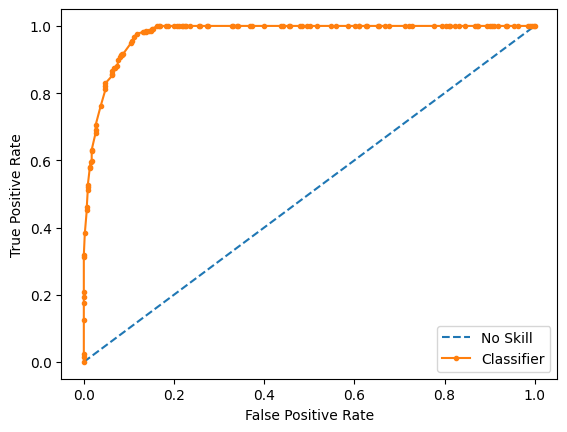

In [ ]:
RL_report=classification_report(y_test, y_predicted)
print("Classification report:")
print(RL_report)
acuratetea_RL=accuracy_score(y_test, y_predicted)
print("Acuratetea RL: ", acuratetea_RL)
roc_auc_curve_plot(RL, X_test, y_test)
acc_df.loc[len(acc_df)] = ['RL', accuracy_score(y_test,y_predicted), f1_score(y_test,y_predicted, average='weighted')]

Axele:

X (False Positive Rate - FPR): Proporția cazurilor negative clasificate greșit ca pozitive.

Y (True Positive Rate - TPR): Proporția cazurilor pozitive clasificate corect ca pozitive.

Linia albastră ("No Skill"):

Reprezintă un model care ghicește aleator. Aceasta are un AUC (Area Under the Curve) de 0.5 și este o linie diagonală.

Linia portocalie ("Classifier"):

Reprezintă modelul. Cu cât curba se apropie mai mult de colțul din stânga sus (TPR mare, FPR mic), cu atât modelul este mai bun

In [ ]:
y_prob=pd.DataFrame(RL.predict_proba(X_test), columns=['RL_0', 'RL_1'])

Aplicarea modelului RL pentru estimarea probabilitatii achizitiei unui game box de catre un client din setul de test